In [42]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [43]:
input_path="../../data/data_origin/data.csv"

In [44]:
df=pd.read_csv(input_path)
df.head()

,url,listing_id,scrape_time,title,phone_number,description,transaction_type,city,district,property_type,project_name_breadcrumb,price,price_per_m2,area,bedrooms,bathrooms,house_direction,balcony_direction,legal,interior,project_name,project_status,developer,posted_date,expired_date,listing_type,latitude,longitude,price_billion,area_m2,ppm2_million_site,ppm2_million_calc,bedrooms_num,bathrooms_num
0,https://batdongsan.com.vn/ban-can-ho-chung-cu-...,44361465,2026-02-18 14:43:55.889906,Suất ngoại giao chiết khấu 18% căn hộ Global C...,0902 919 *** · Hiện số,Chính thức nhận booking 100 triệu/suất (có hoà...,Bán,Hồ Chí Minh,Quận 2,Căn hộ chung cư,Masteri Park Place,8 tỷ,"~98,76 triệu/m²",81 m²,1 PN,1 phòng,NaN,NaN,Hợp đồng mua bán,NaN,Masteri Park Place,Đang cập nhật tiến độ,Masterise Homes,2026-02-14,2026-02-21,Tin VIP Kim Cương,10.805961,106.771976,8.0,81.00,98.76,98.765432,1.0,1.0
1,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,44944822,2026-02-18 14:44:25.065031,"Giỏ hàng nhà liền kề từ 10.1 tỷ, biệt thự 18 t...",0903 040 *** · Hiện số,"Giỏ hàng Nhà phố Liền kề, Biệt thự Song lập, B...",Bán,Hồ Chí Minh,Cần Giờ,"Nhà biệt thự, liền kề",Vinhomes Green Paradise,"10,1 tỷ","~144,29 triệu/m²",70 m²,4 PN,3 phòng,Nam,NaN,Hợp đồng mua bán,NaN,Vinhomes Green Paradise,Đang mở bán,Tập đoàn Vingroup,2026-02-10,2026-02-17,Tin thường,10.386010,106.919039,10.1,70.00,144.29,144.285714,4.0,3.0
2,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,45088296,2026-02-18 14:44:37.776666,"Nhà đẹp 5 tầng kiên cố An Phú, quận 2 4,8x22m ...",0901 353 *** · Hiện số,"Địa chỉ: 20 Đường 16, Phường An Phú, Quận 2.\r...",Bán,Hồ Chí Minh,Quận 2,Nhà mặt phố,đường 16,"27,5 tỷ","~261,9 triệu/m²",105 m²,5 PN,6 phòng,Đông - Nam,Đông - Nam,Sổ đỏ/ Sổ hồng,Đầy đủ,NaN,NaN,NaN,2026-02-14,2026-03-01,Tin thường,10.807645,106.780051,27.5,105.00,261.90,261.904762,5.0,6.0
3,https://batdongsan.com.vn/ban-nha-rieng-phuong...,45056853,2026-02-18 14:44:51.023655,Cư Xá Ngân Hàng - Nhà mới - Thang máy - 5*20m ...,0385 462 *** · Hiện số,"Nhà mới, full nội thất, thang máy xịn xò, 5 tầ...",Bán,Hồ Chí Minh,Quận 7,Nhà riêng,phường Tân Thuận Tây,22 tỷ,"~239,13 triệu/m²",92 m²,6 PN,7 phòng,NaN,NaN,Sổ đỏ/ Sổ hồng,Đầy đủ,NaN,NaN,NaN,2026-02-03,2026-02-18,Tin thường,10.751216,106.722497,22.0,92.00,239.13,239.130435,6.0,7.0
4,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,45088269,2026-02-18 14:45:05.529925,Bán nhà trung tâm quận 1 p. Tân Định thang máy...,0901 353 *** · Hiện số,Bán nhà trung tâm quận 1 P. Tân Định thang máy...,Bán,Hồ Chí Minh,Quận 1,Nhà mặt phố,đường Nguyễn Văn Nguyễn,"25,5 tỷ","~389,61 triệu/m²","65,45 m²",5 PN,6 phòng,Đông - Bắc,Đông - Bắc,Sổ đỏ/ Sổ hồng,Đầy đủ,NaN,NaN,NaN,2026-02-09,2026-02-24,Tin thường,10.793310,106.687257,25.5,65.45,389.61,389.610390,5.0,6.0


#### **Process data**

##### Process unit of numeric value

In [45]:
# Extract unit
def extract_unit_only(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    match = re.search(r"[0-9\.,]+\s*(.*)", s)
    if match:
        unit = match.group(1).strip()
        return unit if unit != "" else "(no unit)"
    return "(no match)"

cols = ["price", "price_per_m2", "area", "bedrooms", "bathrooms"]
for col in cols:
    print(f"\nCOLUMN: {col}")
    units = df[col].apply(extract_unit_only)
    print("Unique unit count:", units.nunique(dropna=True))
    print("Top units:")
    print(units.value_counts(dropna=False))


COLUMN: price
Unique unit count: 2
Top units:
price
tỷ       3060
triệu       7
Name: count, dtype: int64

COLUMN: price_per_m2
Unique unit count: 3
Top units:
price_per_m2
triệu/m²    3058
tỷ/m²          8
nghìn/m²       1
Name: count, dtype: int64

COLUMN: area
Unique unit count: 1
Top units:
area
m²    3067
Name: count, dtype: int64

COLUMN: bedrooms
Unique unit count: 1
Top units:
bedrooms
pn      2266
None     801
Name: count, dtype: int64

COLUMN: bathrooms
Unique unit count: 1
Top units:
bathrooms
phòng    2155
None      912
Name: count, dtype: int64


In [46]:
# Helper parse number VN format
def vn_number(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower()
    s = re.sub(r"[^\d\.,]", "", s)
    
    if s.count(",") > 0 and s.count(".") > 0:
        s = s.replace(".", "").replace(",", ".")
    elif s.count(",") > 0:
        s = s.replace(",", ".")
    elif s.count(".") > 1:
        s = s.replace(".", "")
        
    try:
        return float(s)
    except:
        return np.nan

# Convert price
def parse_price(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower()
    num = vn_number(s)
    if np.isnan(num):
        return np.nan
    
    if "triệu" in s:
        return num * 0.001
    if "tỷ" in s:
        return num
    return np.nan


# Convert price per m^2
def parse_ppm2(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower()
    num = vn_number(s)
    if np.isnan(num):
        return np.nan
    
    if "triệu" in s:
        return num * 0.001
    if "nghìn" in s:
        return num * 1e-6
    if "tỷ" in s:
        return num
    return np.nan

In [47]:
df["price"] = df["price"].apply(parse_price)
df["price_per_m2"] = df["price_per_m2"].apply(parse_ppm2)
df["area"] = df["area"].apply(vn_number)
df["bedrooms"] = df["bedrooms"].apply(vn_number)
df["bathrooms"] = df["bathrooms"].apply(vn_number)

# Check
print(df[["price","price_per_m2","area","bedrooms","bathrooms"]].dtypes)
print(df[["price","price_per_m2","area","bedrooms","bathrooms"]].head())

price           float64
price_per_m2    float64
area            float64
bedrooms        float64
bathrooms       float64
dtype: object
   price  price_per_m2    area  bedrooms  bathrooms
0    8.0       0.09876   81.00       1.0        1.0
1   10.1       0.14429   70.00       4.0        3.0
2   27.5       0.26190  105.00       5.0        6.0
3   22.0       0.23913   92.00       6.0        7.0
4   25.5       0.38961   65.45       5.0        6.0


##### Handle missing data

In [48]:
for col in ["price_per_m2", "area", "bedrooms", "bathrooms"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[(df["price_per_m2"] > 0) & (df["area"] > 0)]
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].median())
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())
df["property_type"] = df["property_type"].fillna("unknown")

##### Transform data

In [49]:
# Log price
df["log_ppm2"] = np.log1p(df["price_per_m2"])
df["log_area"] = np.log1p(df["area"])

# Choose column for transform
num_cols = ["log_ppm2", "log_area", "bedrooms", "bathrooms"]
cat_cols = ["property_type"]
preprocess = ColumnTransformer([
    ("num", RobustScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [50]:
X = preprocess.fit_transform(df)
X.shape

(3067, 14)

#### **Clustering**

##### Find number clusters in data

In [51]:
k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

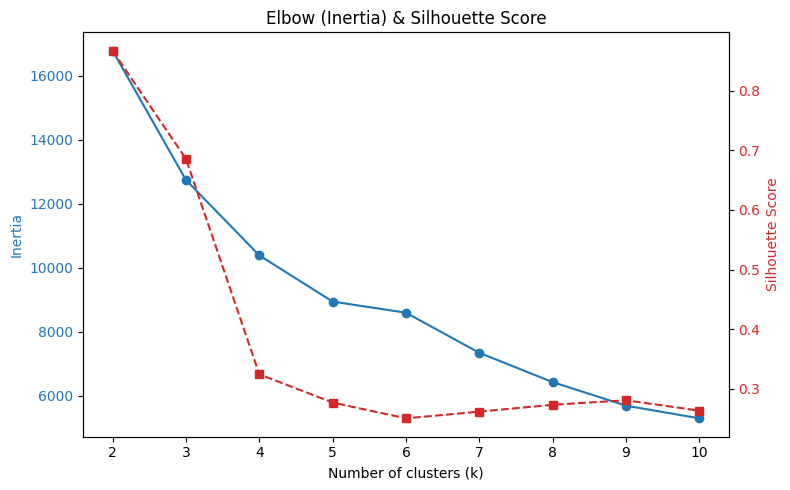

In [52]:
fig, ax1 = plt.subplots(figsize=(8,5))

# Elbow (Inertia)
color = "tab:blue"
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia", color=color)
ax1.plot(k_range, inertias, marker="o", color=color)
ax1.tick_params(axis="y", labelcolor=color)

# Silhouette score
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Silhouette Score", color=color)
ax2.plot(k_range, sil_scores, marker="s", linestyle="--", color=color)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Elbow (Inertia) & Silhouette Score")
plt.tight_layout()
plt.show()

**Define metrics**

`Inertia` = the total distance between data points and the center of their cluster.
- Smaller inertia → clusters are more compact
- Used to measure how tight the clusters are

When increasing the number of clusters (k), inertia decreases.
Plot:
- X-axis = number of clusters (k)
- Y-axis = inertia
Choose k at the “elbow” point — where inertia starts decreasing more slowly.
→ Enough clusters, but not too many.

=======================================================================================

`Silhouette` score measures how well a point fits in its cluster. Value range: -1 to 1
- Close to 1 → good clustering
- Close to 0 → overlapping clusters
- Less than 0 → wrong clustering

→ Higher is better.

**==> Chosse k = 3 because the inertia and silhouette score are best at this point.**

##### Cluster with best k

In [53]:
k = 3
model_k3 = Pipeline([
    ("prep", preprocess),
    ("km", KMeans(n_clusters=k, n_init="auto", random_state=42))
])

df["cluster"] = model_k3.fit_predict(df)

print("Cluster counts:")
print(df["cluster"].value_counts().sort_index())

Cluster counts:
cluster
0    2966
1      93
2       8
Name: count, dtype: int64


In [54]:
df["ppm2_million"] = df["price_per_m2"] * 1000  

profile = df.groupby("cluster").agg(
    n=("cluster", "size"),
    median_ppm2_million=("ppm2_million", "median"),
    median_area=("area", "median"),
    mean_bedrooms=("bedrooms", "mean"),
    mean_bathrooms=("bathrooms", "mean"),
    median_price_ty=("price", "median")  
).sort_values("n", ascending=False)

print("=== Cluster profile (k=3) ===")
print(profile.to_string())

=== Cluster profile (k=3) ===
            n  median_ppm2_million  median_area  mean_bedrooms  mean_bathrooms  median_price_ty
cluster                                                                                        
0        2966              116.930        78.75       3.162508        3.035064              8.3
1          93              190.000       125.00      14.032258       13.075269             25.0
2           8              192.555       220.00      50.875000       51.500000             50.2


In [55]:
top_pt = (
    df.groupby(["cluster", "property_type"])
      .size()
      .reset_index(name="count")
      .sort_values(["cluster", "count"], ascending=[True, False])
      .groupby("cluster")
      .head(5)
)

print("=== Top property_type per cluster ===")
for c in sorted(df["cluster"].unique()):
    sub = top_pt[top_pt["cluster"] == c]
    items = ", ".join([f"{r['property_type']} ({int(r['count'])})" for _, r in sub.iterrows()])
    print(f"Cluster {c}: {items}")

=== Top property_type per cluster ===
Cluster 0: Nhà riêng (1249), Căn hộ chung cư (745), Nhà mặt phố (426), Bán đất (271), Nhà biệt thự, liền kề (195)
Cluster 1: Nhà riêng (57), Nhà mặt phố (34), Chung cư mini, căn hộ dịch vụ (1), Nhà biệt thự, liền kề (1)
Cluster 2: Nhà riêng (5), Nhà mặt phố (3)


In [56]:
show_cols = ["listing_id","district","property_type","price","ppm2_million","area","bedrooms","bathrooms","cluster"]
show_cols = [c for c in show_cols if c in df.columns]

print("=== Samples (5 rows) per cluster ===")
for c in sorted(df["cluster"].unique()):
    print(f"\n--- Cluster {c} ---")
    print(df[df["cluster"] == c][show_cols].head(5).to_string(index=False))

=== Samples (5 rows) per cluster ===

--- Cluster 0 ---
 listing_id district         property_type  price  ppm2_million   area  bedrooms  bathrooms  cluster
   44361465   Quận 2       Căn hộ chung cư    8.0         98.76  81.00       1.0        1.0        0
   44944822  Cần Giờ Nhà biệt thự, liền kề   10.1        144.29  70.00       4.0        3.0        0
   45088296   Quận 2           Nhà mặt phố   27.5        261.90 105.00       5.0        6.0        0
   45056853   Quận 7             Nhà riêng   22.0        239.13  92.00       6.0        7.0        0
   45088269   Quận 1           Nhà mặt phố   25.5        389.61  65.45       5.0        6.0        0

--- Cluster 1 ---
 listing_id   district property_type  price  ppm2_million  area  bedrooms  bathrooms  cluster
   42700245 Bình Thạnh     Nhà riêng  56.00        313.90 178.4      23.0        3.0        1
   45109963     Quận 2     Nhà riêng 118.00        483.61 244.0      12.0       16.0        1
   44353731     Quận 6     Nhà riêng 

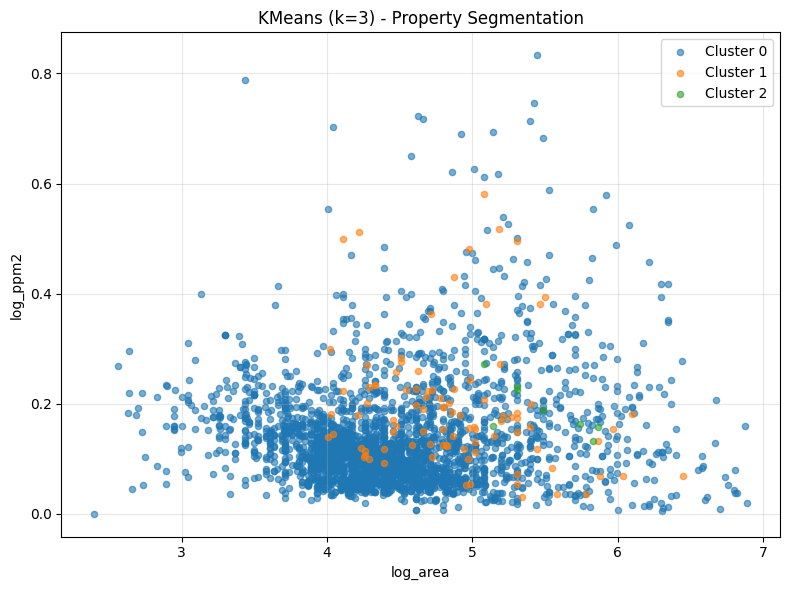

In [57]:
plt.figure(figsize=(8,6))
for c in sorted(df["cluster"].unique()):
    sub = df[df["cluster"] == c]
    plt.scatter(
        sub["log_area"],
        sub["log_ppm2"],
        s=20,
        alpha=0.6,
        label=f"Cluster {c}"
    )

plt.xlabel("log_area")
plt.ylabel("log_ppm2")
plt.title("KMeans (k=3) - Property Segmentation")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()